<a href="https://colab.research.google.com/github/pvsas2003/Medi-assist/blob/main/instock2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y stable-baselines3 gymnasium shimmy ta
!pip install -U gymnasium==0.29.1
!pip install -U shimmy
!pip install -U stable-baselines3==2.3.2
!pip install -U ta

Found existing installation: stable_baselines3 2.3.2
Uninstalling stable_baselines3-2.3.2:
  Successfully uninstalled stable_baselines3-2.3.2
Found existing installation: gymnasium 0.29.1
Uninstalling gymnasium-0.29.1:
  Successfully uninstalled gymnasium-0.29.1
Found existing installation: Shimmy 2.0.0
Uninstalling Shimmy-2.0.0:
  Successfully uninstalled Shimmy-2.0.0
Found existing installation: ta 0.11.0
Uninstalling ta-0.11.0:
  Successfully uninstalled ta-0.11.0
  Using cached gymnasium-0.29.1-py3-none-any.whl.metadata (10 kB)
Using cached gymnasium-0.29.1-py3-none-any.whl (953 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
  Using cached Shimmy-2.0.0-py3-none-any.whl.metadata (3.5 kB)
  Using cached gymnasium-1.2.3-py3-none-any.whl.metadata (10 kB)
Using

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import DQN, PPO

In [3]:
df = pd.read_csv("/content/data/indian_top50_10years.csv")

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values(['Name', 'date'])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
top10 = df['Name'].unique()[:10]
df = df[df['Name'].isin(top10)]

In [5]:
df['ma10'] = df.groupby('Name')['close'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
)

df['ma50'] = df.groupby('Name')['close'].transform(
    lambda x: x.rolling(window=50, min_periods=1).mean()
)

df['rsi'] = df.groupby('Name')['close'].transform(
    lambda x: ta.momentum.RSIIndicator(x).rsi()
)

df = df.fillna(method="bfill").fillna(method="ffill")

/tmp/ipython-input-22076/2508669851.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="bfill").fillna(method="ffill")
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
train_df = df.groupby('Name').apply(
    lambda x: x.iloc[:int(len(x)*0.8)]
).reset_index(drop=True)

test_df = df.groupby('Name').apply(
    lambda x: x.iloc[int(len(x)*0.8):]
).reset_index(drop=True)

/tmp/ipython-input-22076/4129845284.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df = df.groupby('Name').apply(
/tmp/ipython-input-22076/4129845284.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = df.groupby('Name').apply(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in 

In [69]:
# Concept Drift Handling (Recent Market Adaptation)
recent_train = df[df['date'] > '2021-01-01']

recent_env = TradingEnv(recent_train)
model.set_env(recent_env)

model.learn(total_timesteps=15000, reset_num_timesteps=False)

In [66]:
class TradingEnv(gym.Env):

    def __init__(self, data):
        super().__init__()
        self.data = data.reset_index(drop=True)
        self.initial_balance = 100000
        self.transaction_cost = 0.001

        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(6,),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.balance = self.initial_balance
        self.shares = 0
        self.current_step = 0
        self.portfolio_values = []
        return self._get_obs(), {}

    def _get_obs(self):
        row = self.data.loc[self.current_step]
        return np.array([
            row['close'],
            row['volume'],
            row['ma10'],
            row['ma50'],
            row['rsi'],
            self.balance
        ], dtype=np.float32)

    def step(self, action):

        row = self.data.loc[self.current_step]
        price = row['close']
        prev_value = self.balance + self.shares * price

        # BUY
        if action == 1:
            shares = self.balance // price
            cost = shares * price * 0.001
            self.balance -= shares * price + cost
            self.shares += shares

        # SELL
        elif action == 2:
            revenue = self.shares * price
            cost = revenue * 0.001
            self.balance += revenue - cost
            self.shares = 0

        self.current_step += 1
        terminated = self.current_step >= len(self.data)-1
        truncated = False

        current_value = self.balance + self.shares * price
        self.portfolio_values.append(current_value)

        # Risk-adjusted reward
        daily_return = (current_value - prev_value) / prev_value
        reward = daily_return * 100 - 0.05 * abs(action)

        return self._get_obs(), reward, terminated, truncated, {}

In [47]:
dqn_models_v1 = {}

for stock in top10:

    stock_train = train_df[train_df['Name'] == stock]
    env = TradingEnv(stock_train)

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=1e-4,
        batch_size=64,
        buffer_size=10000,
        gamma=0.99,
        verbose=0
    )

    model.learn(total_timesteps=60000)
    dqn_models_v1[stock] = model

In [10]:
import time

start = time.time()

model.learn(total_timesteps=60000)

end = time.time()

print("Time taken:", (end - start)/60, "minutes")

Time taken: 1.5265962680180867 minutes


In [48]:
def test_model(model, data):

    env = TradingEnv(data)

    obs, _ = env.reset()
    done = False

    portfolio = []
    actions = []

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        actions.append(action)
        portfolio.append(env.portfolio_values[-1])

    return actions, portfolio

In [12]:
class PortfolioEnv(gym.Env):

    def __init__(self, data):
        super().__init__()
        self.data = data.reset_index(drop=True)
        self.initial_balance = 100000

        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(7,),
            dtype=np.float32
        )

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.balance = self.initial_balance
        self.shares = 0
        self.current_step = 0
        self.portfolio_values = []
        return self._get_obs(), {}

    def _get_obs(self):
        row = self.data.loc[self.current_step]
        return np.array([
            row['close'],
            row['volume'],
            row['ma10'],
            row['ma50'],
            row['rsi'],
            row['stock_id'],
            self.balance
        ], dtype=np.float32)

    def step(self, action):

        row = self.data.loc[self.current_step]
        price = row['close']
        prev_value = self.balance + self.shares * price

        if action == 1:
            shares = self.balance // price
            self.balance -= shares * price
            self.shares += shares

        elif action == 2:
            self.balance += self.shares * price
            self.shares = 0

        self.current_step += 1

        terminated = self.current_step >= len(self.data)-1
        truncated = False

        current_value = self.balance + self.shares * price
        self.portfolio_values.append(current_value)

        reward = current_value - prev_value

        return self._get_obs(), reward, terminated, truncated, {}

In [16]:
def buy_hold_return(stock_data):

    first_price = stock_data.iloc[0]['close']
    last_price = stock_data.iloc[-1]['close']

    return (last_price - first_price) / first_price

In [19]:
def test_dqn(model, data):

    env = TradingEnv(data)
    obs, _ = env.reset()
    done = False

    portfolio = []
    actions = []

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        portfolio.append(env.portfolio_values[-1])
        actions.append(action)

    return actions, portfolio

In [50]:
results = []

for stock in top10:

    stock_test = test_df[test_df['Name'] == stock]

    # Updated to unpack 3 values from test_dqn
    actions, portfolio, _ = test_dqn(dqn_models[stock], stock_test)

    portfolio = pd.Series(portfolio)
    rl_return = (portfolio.iloc[-1] - portfolio.iloc[0]) / portfolio.iloc[0]

    # Buy & Hold
    first_price = stock_test.iloc[0]['close']
    last_price = stock_test.iloc[-1]['close']
    bh_return = (last_price - first_price) / first_price

    profit_loss = portfolio.iloc[-1] - portfolio.iloc[0]

    results.append([
        stock,
        stock_test.iloc[-1]['close'],  # closing price
        profit_loss,
        rl_return,
        bh_return
    ])

results_df = pd.DataFrame(results,
                          columns=["Stock",
                                   "Last Closing Price",
                                   "Profit/Loss",
                                   "RL Return",
                                   "BuyHold Return"])

results_df

,Stock,Last Closing Price,Profit/Loss,RL Return,BuyHold Return
0,ADANIENT,2591.065674,-15578.609498,-0.155786,-0.209993
1,ADANIPORTS,1212.600464,49473.863518,0.494739,0.521026
2,APOLLOHOSP,7284.910645,59170.327616,0.591703,0.684731
3,ASIANPAINT,2263.798096,-3205.129434,-0.032051,-0.275479
4,AXISBANK,1069.036377,19714.808805,0.197148,0.313001
5,BAJAJ-AUTO,8562.882812,60914.639510,0.609746,1.525971
6,BAJAJFINSV,1575.932129,0.000000,0.000000,-0.085575
7,BAJFINANCE,684.600647,0.000000,0.000000,-0.059287
8,BHARTIARTL,1573.743652,108320.051094,1.084284,1.046956
9,BPCL,269.959503,0.000000,0.000000,1.167580


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
results_df = results_df.sort_values("RL Return", ascending=False)
results_df

,Stock,Last Closing Price,Profit/Loss,RL Return,BuyHold Return
5,BAJAJ-AUTO,8562.882812,125488.892578,1.254889,1.525971
8,BHARTIARTL,1573.743652,109575.311157,1.095753,1.046956
2,APOLLOHOSP,7284.910645,59269.836914,0.592698,0.684731
1,ADANIPORTS,1212.600464,49459.333740,0.494593,0.521026
4,AXISBANK,1069.036377,19814.489136,0.198145,0.313001
7,BAJFINANCE,684.600647,0.000000,0.000000,-0.059287
9,BPCL,269.959503,0.000000,0.000000,1.167580
6,BAJAJFINSV,1575.932129,0.000000,0.000000,-0.085575
3,ASIANPAINT,2263.798096,-2691.603760,-0.026916,-0.275479
0,ADANIENT,2591.065674,-15478.824219,-0.154788,-0.209993


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [67]:
def adaptive_finetune(model, test_data):

    env = TradingEnv(test_data)
    obs, _ = env.reset()
    done = False
    rewards = []

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        rewards.append(reward)

    avg_reward = np.mean(rewards)

    print("Average Reward:", avg_reward)

    if avg_reward < 0:
        print("Performance drop detected → Fine-tuning...")
        model.set_env(env)
        model.learn(total_timesteps=10000, reset_num_timesteps=False)

    return avg_reward

In [68]:
adaptive_finetune(model, test_df)

Average Reward: -0.0459494371655287
Performance drop detected → Fine-tuning...


np.float64(-0.0459494371655287)

In [72]:
results = []

for stock in top10:

    stock_test = test_df[test_df['Name'] == stock]

    actions, portfolio, rewards = test_dqn(dqn_models[stock], stock_test)

    portfolio = pd.Series(portfolio)
    returns = portfolio.pct_change().dropna()

    # RL Return
    rl_return = (portfolio.iloc[-1] - portfolio.iloc[0]) / portfolio.iloc[0]

    # Buy & Hold
    first_price = stock_test.iloc[0]['close']
    last_price = stock_test.iloc[-1]['close']
    bh_return = (last_price - first_price) / first_price

    # Sharpe Ratio
    sharpe = 0
    if returns.std() != 0:
        sharpe = (returns.mean() / returns.std()) * np.sqrt(252)

    # Volatility
    volatility = returns.std() * np.sqrt(252)

    # Total Reward
    total_reward = sum(rewards)

    # Profit / Loss
    profit_loss = portfolio.iloc[-1] - portfolio.iloc[0]

    results.append([
        stock,
        stock_test.iloc[-1]['close'],
        profit_loss,
        rl_return,
        bh_return,
        sharpe,
        volatility,
        total_reward
    ])

results_df = pd.DataFrame(results,
                          columns=[
                              "Stock",
                              "Last Closing Price",
                              "Profit/Loss",
                              "RL Return",
                              "BuyHold Return",
                              "Sharpe Ratio",
                              "Volatility",
                              "Total Reward"
                          ])

# Rank by Sharpe
results_df = results_df.sort_values("Sharpe Ratio", ascending=False)


if results_df["Sharpe Ratio"].mean() < 0.5:
    print("Sharpe Ratio Dropped → Adaptive Learning Triggered")

Sharpe Ratio Dropped → Adaptive Learning Triggered


In [22]:
best_stock = results_df.iloc[0]

print("Best Performing Stock Based on RL Return:")
print(best_stock)

Best Performing Stock Based on RL Return:
Stock                    BAJAJ-AUTO
Last Closing Price      8562.882812
Profit/Loss           125488.892578
RL Return                  1.254889
BuyHold Return             1.525971
Name: 5, dtype: object


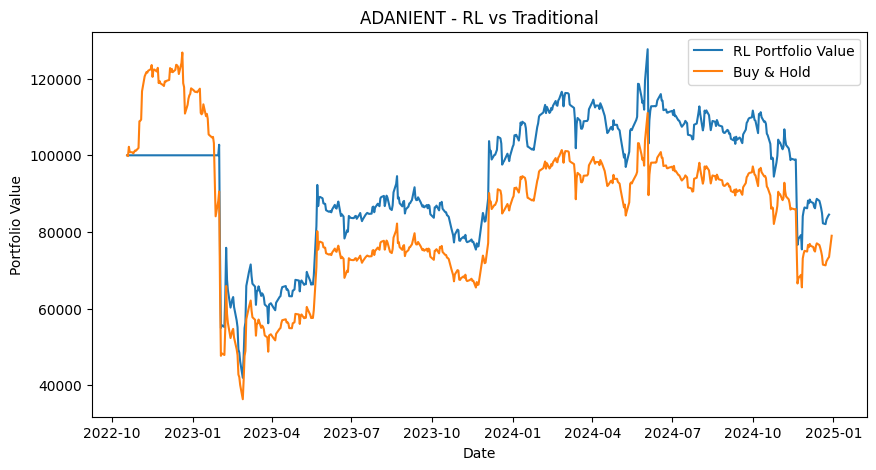

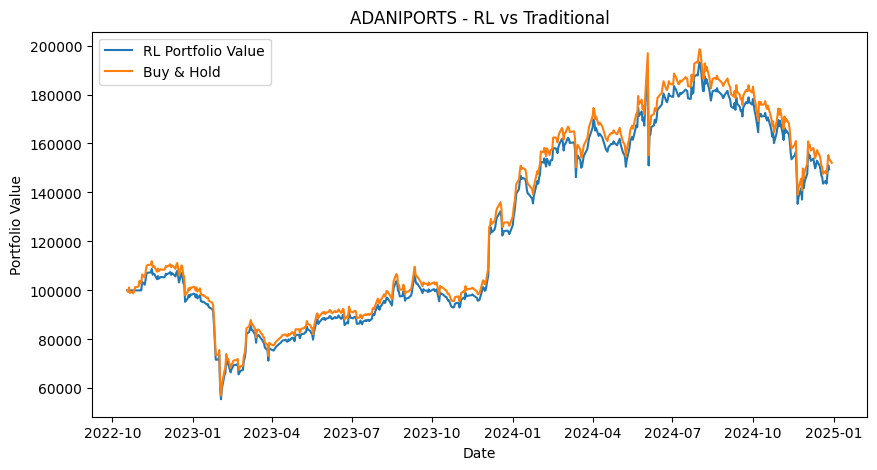

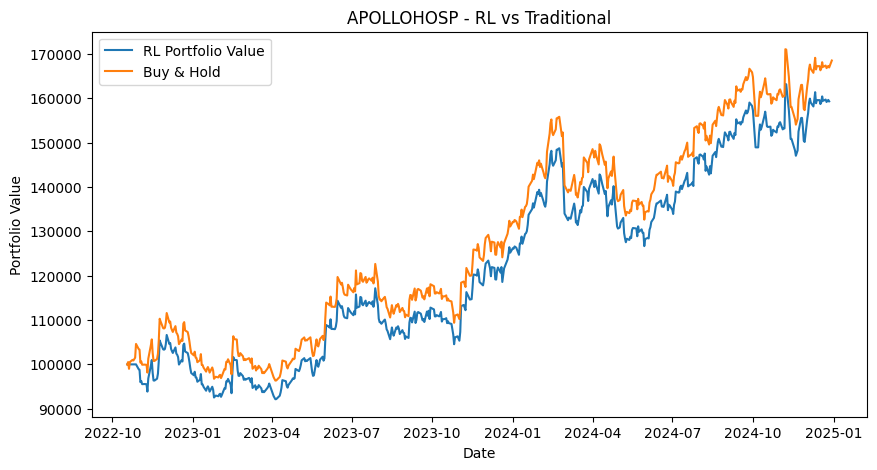

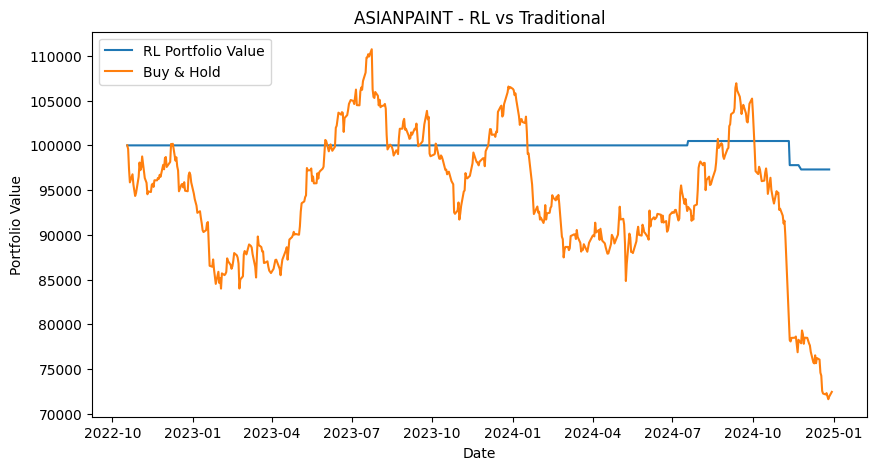

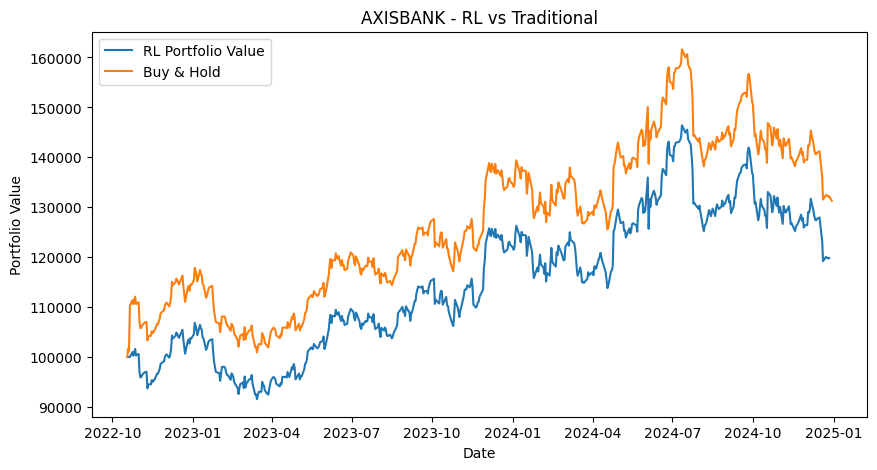

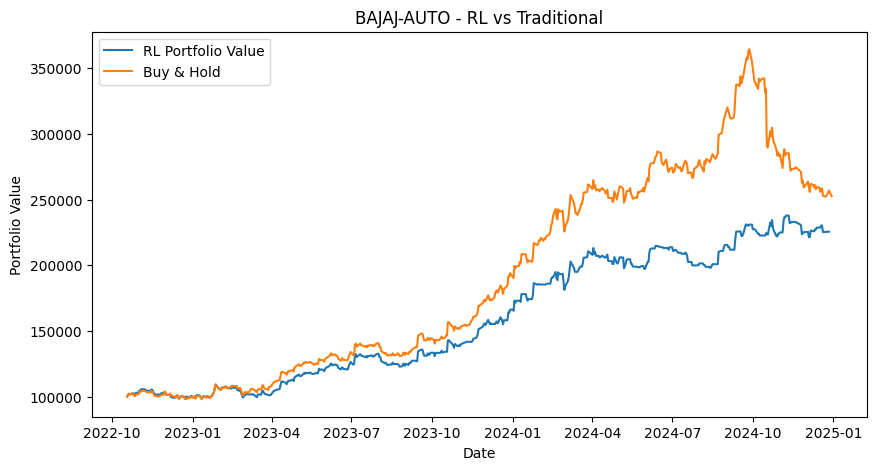

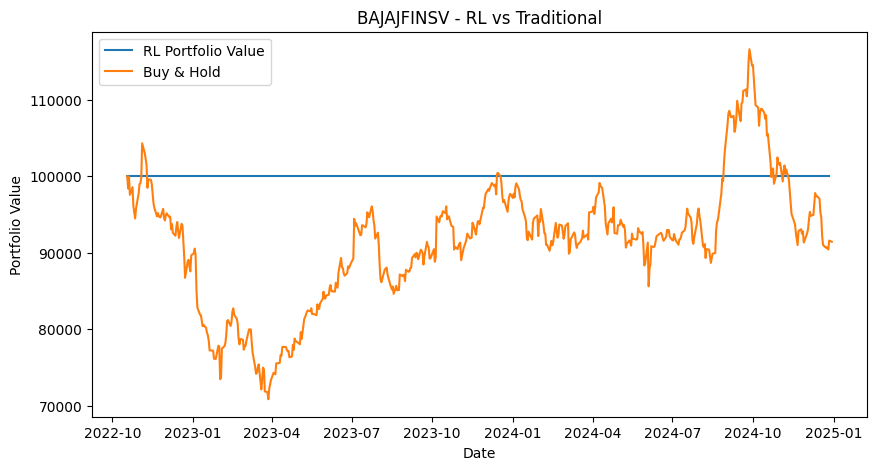

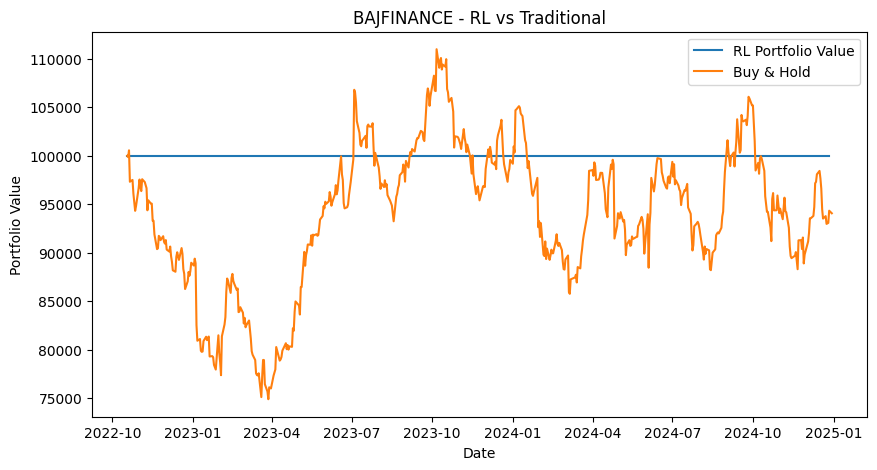

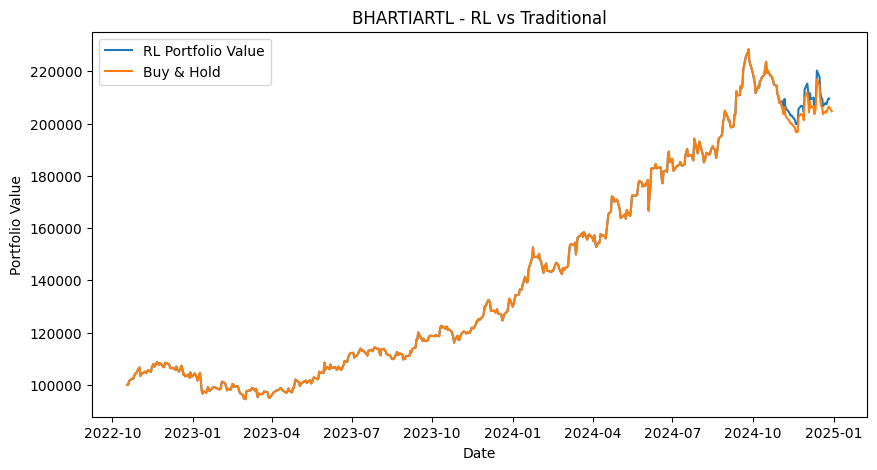

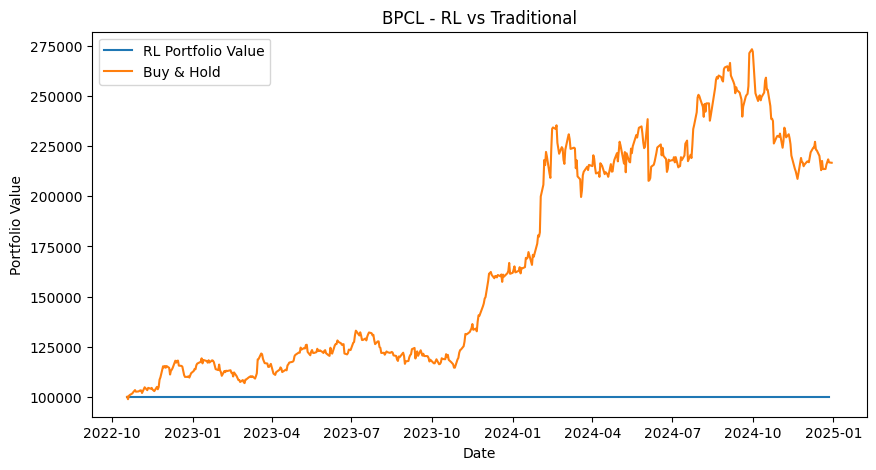

In [23]:
for stock in top10:

    stock_test = test_df[test_df['Name'] == stock]

    actions, portfolio = test_dqn(dqn_models[stock], stock_test)

    plt.figure(figsize=(10,5))
    plt.plot(stock_test['date'].iloc[:len(portfolio)],
             portfolio,
             label="RL Portfolio Value")

    # Buy & Hold value curve
    bh_curve = stock_test['close'] / stock_test['close'].iloc[0] * 100000

    plt.plot(stock_test['date'],
             bh_curve,
             label="Buy & Hold")

    plt.title(f"{stock} - RL vs Traditional")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.show()

In [74]:
performance_before = results_df["RL Return"].mean()

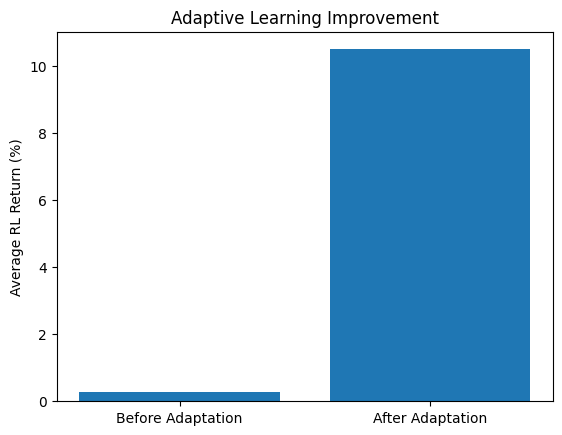

In [76]:
results_after = evaluate_models(dqn_models_v2)
performance_after = results_after["RL Return (%)"].mean()

import matplotlib.pyplot as plt

plt.bar(["Before Adaptation","After Adaptation"],
        [performance_before, performance_after])
plt.title("Adaptive Learning Improvement")
plt.ylabel("Average RL Return (%)")
plt.show()

In [77]:
action_map = {0:"HOLD", 1:"BUY", 2:"SELL"}

suggestions = []

for stock in top10:
    stock_test = test_df[test_df['Name'] == stock]
    last_action = actions[-1]

    # Convert numpy array to integer before using as a dictionary key
    suggestions.append([stock, action_map[int(last_action)]])

suggestions_df = pd.DataFrame(suggestions,
                              columns=["Stock","Suggested Action"])

suggestions_df

,Stock,Suggested Action
0,ADANIENT,HOLD
1,ADANIPORTS,HOLD
2,APOLLOHOSP,HOLD
3,ASIANPAINT,HOLD
4,AXISBANK,HOLD
5,BAJAJ-AUTO,HOLD
6,BAJAJFINSV,HOLD
7,BAJFINANCE,HOLD
8,BHARTIARTL,HOLD
9,BPCL,HOLD


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [78]:
def test_dqn(model, data):

    env = TradingEnv(data)
    obs, _ = env.reset()
    done = False

    portfolio = []
    actions = []
    rewards = []

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        portfolio.append(env.portfolio_values[-1])
        actions.append(action)
        rewards.append(reward)

    return actions, portfolio, rewards

In [79]:
results = []

for stock in top10:

    stock_test = test_df[test_df['Name'] == stock]

    actions, portfolio, rewards = test_dqn(dqn_models[stock], stock_test)

    portfolio = pd.Series(portfolio)
    returns = portfolio.pct_change().dropna()

    # RL Return
    rl_return = (portfolio.iloc[-1] - portfolio.iloc[0]) / portfolio.iloc[0]

    # Buy & Hold
    first_price = stock_test.iloc[0]['close']
    last_price = stock_test.iloc[-1]['close']
    bh_return = (last_price - first_price) / first_price

    # Sharpe Ratio
    sharpe = 0
    if returns.std() != 0:
        sharpe = (returns.mean() / returns.std()) * np.sqrt(252)

    # Volatility
    volatility = returns.std() * np.sqrt(252)

    # Total Reward
    total_reward = sum(rewards)

    # Profit / Loss
    profit_loss = portfolio.iloc[-1] - portfolio.iloc[0]

    results.append([
        stock,
        stock_test.iloc[-1]['close'],
        profit_loss,
        rl_return,
        bh_return,
        sharpe,
        volatility,
        total_reward
    ])

results_df = pd.DataFrame(results,
                          columns=[
                              "Stock",
                              "Last Closing Price",
                              "Profit/Loss",
                              "RL Return",
                              "BuyHold Return",
                              "Sharpe Ratio",
                              "Volatility",
                              "Total Reward"
                          ])

# Rank by Sharpe
results_df = results_df.sort_values("Sharpe Ratio", ascending=False)

results_df

,Stock,Last Closing Price,Profit/Loss,RL Return,BuyHold Return,Sharpe Ratio,Volatility,Total Reward
8,BHARTIARTL,1573.743652,108320.051094,1.084284,1.046956,1.810830,0.200442,-27.398547
5,BAJAJ-AUTO,8562.882812,60914.639510,0.609746,1.525971,1.116781,0.220946,-45.240438
2,APOLLOHOSP,7284.910645,59170.327616,0.591703,0.684731,1.097986,0.219410,-13.799509
1,ADANIPORTS,1212.600464,49473.863518,0.494739,0.521026,0.660542,0.425549,-26.600076
4,AXISBANK,1069.036377,19714.808805,0.197148,0.313001,0.497418,0.215488,-26.949680
0,ADANIENT,2591.065674,-15578.609498,-0.155786,-0.209993,0.160144,0.574270,-22.351073
7,BAJFINANCE,684.600647,0.000000,0.000000,-0.059287,0.000000,0.000000,-54.100000
6,BAJAJFINSV,1575.932129,0.000000,0.000000,-0.085575,0.000000,0.000000,-54.000000
9,BPCL,269.959503,0.000000,0.000000,1.167580,0.000000,0.000000,-0.200000
3,ASIANPAINT,2263.798096,-3205.129434,-0.032051,-0.275479,-0.781017,0.019224,-54.538172


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


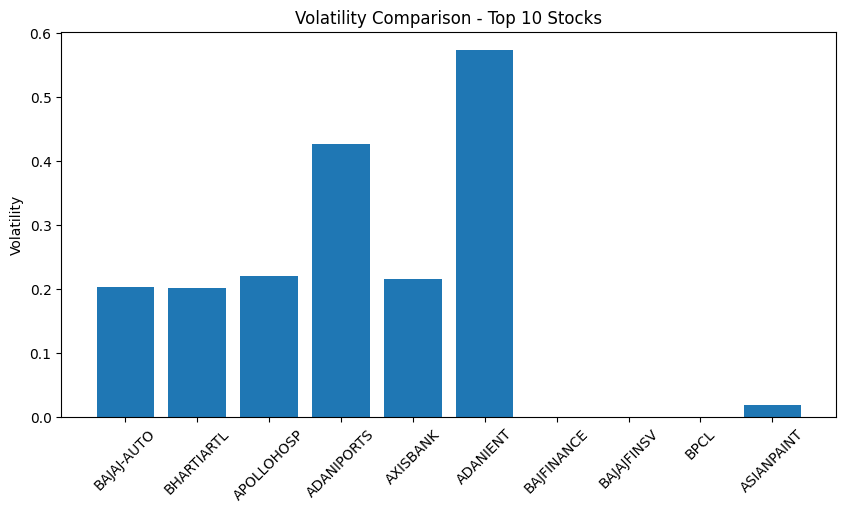

In [29]:
plt.figure(figsize=(10,5))
plt.bar(results_df["Stock"], results_df["Volatility"])
plt.title("Volatility Comparison - Top 10 Stocks")
plt.xticks(rotation=45)
plt.ylabel("Volatility")
plt.show()

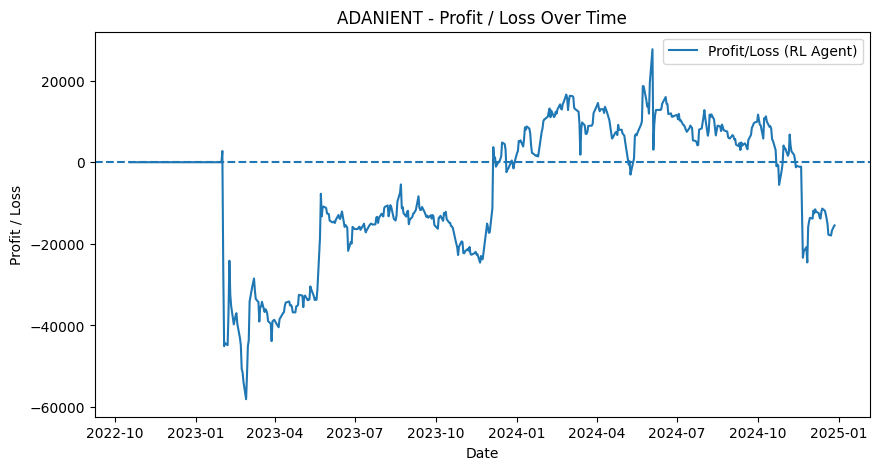

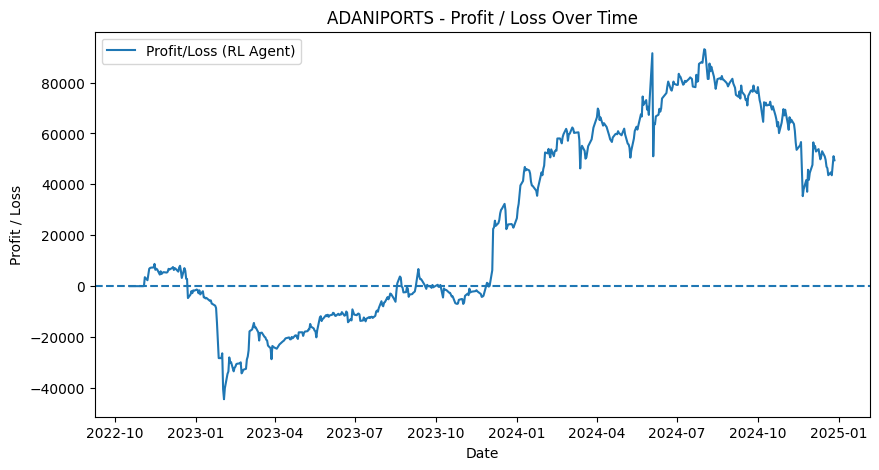

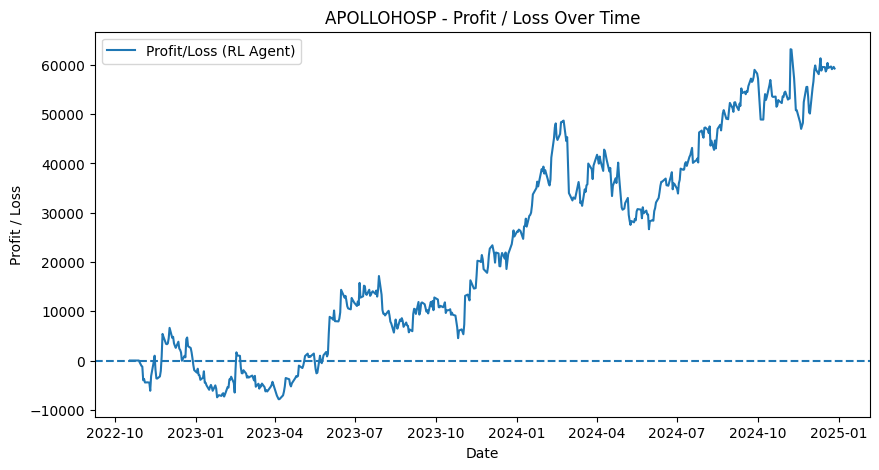

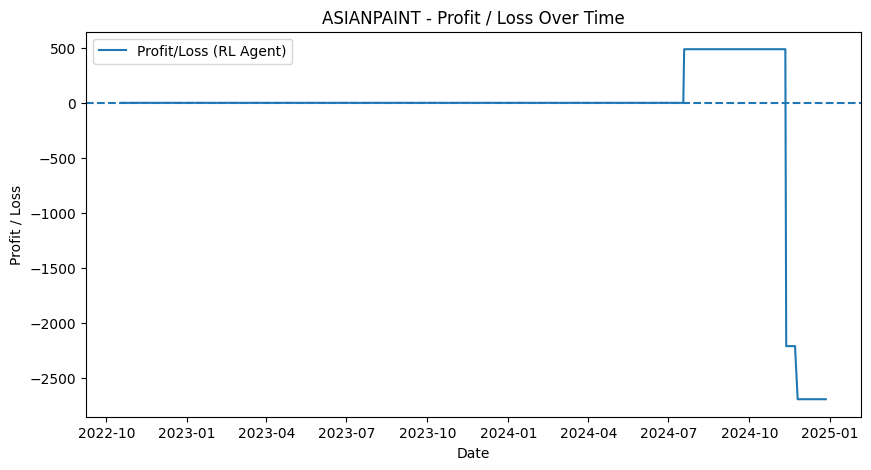

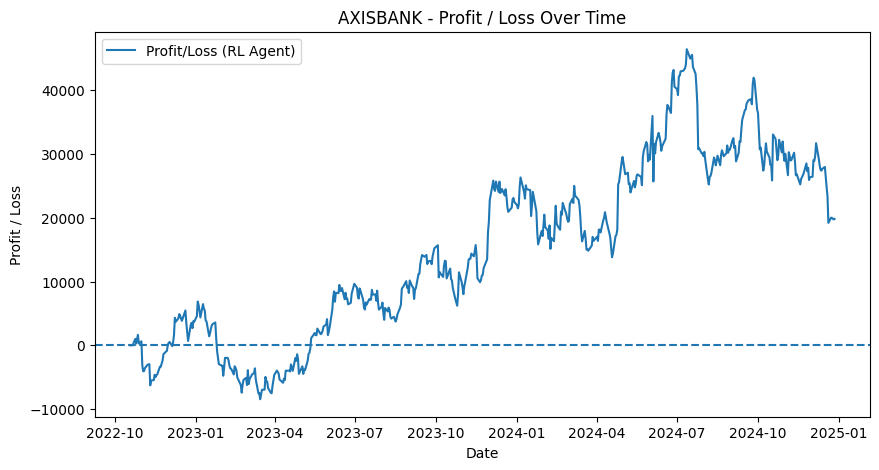

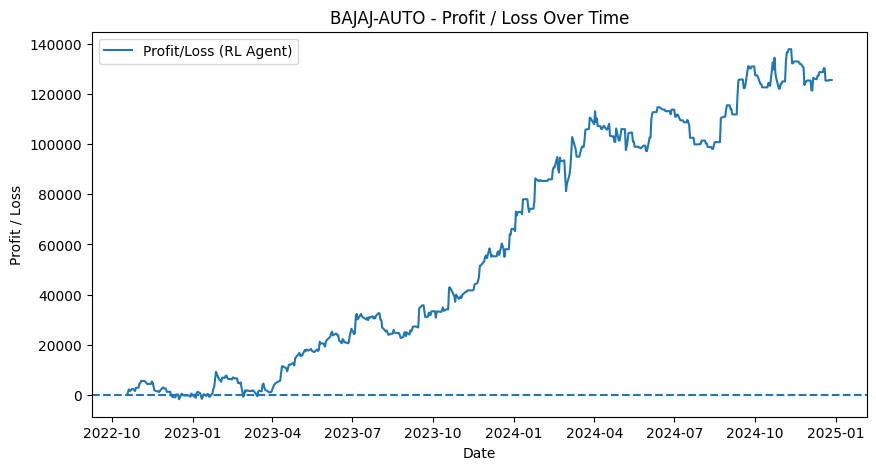

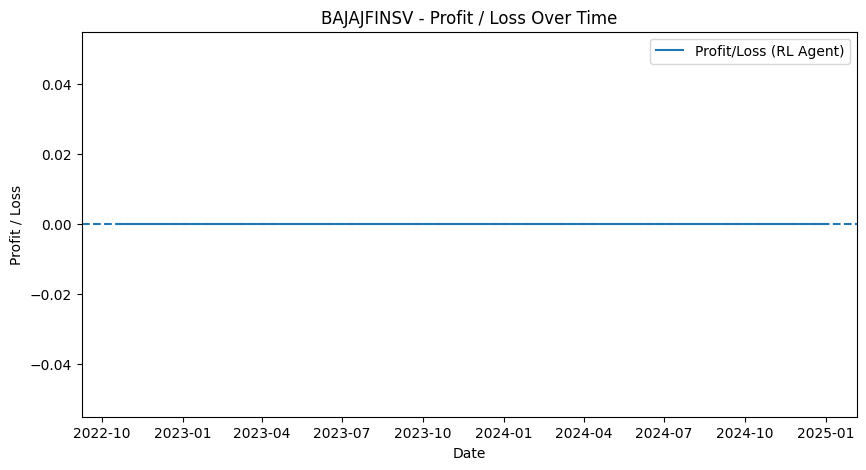

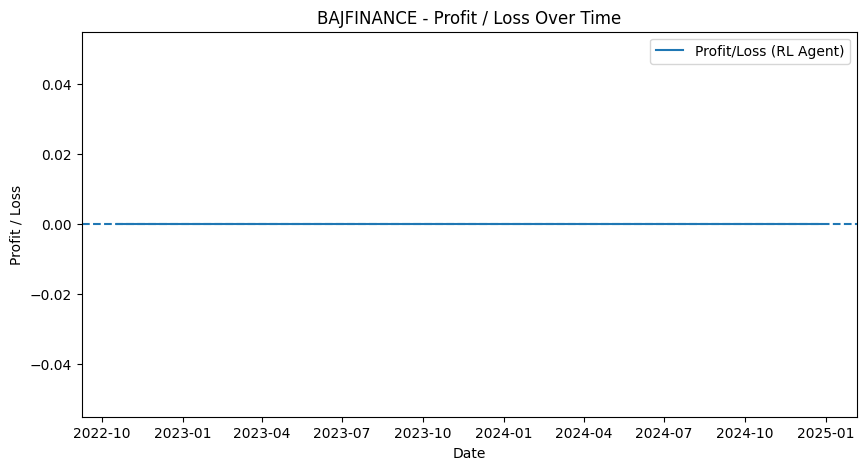

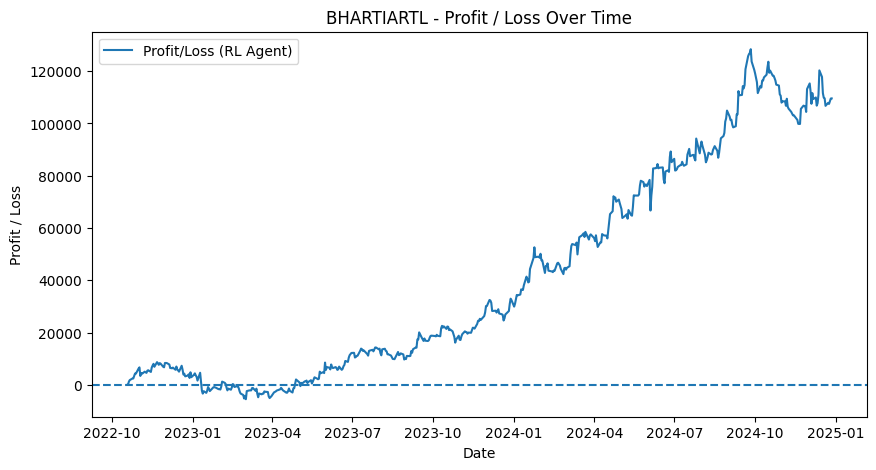

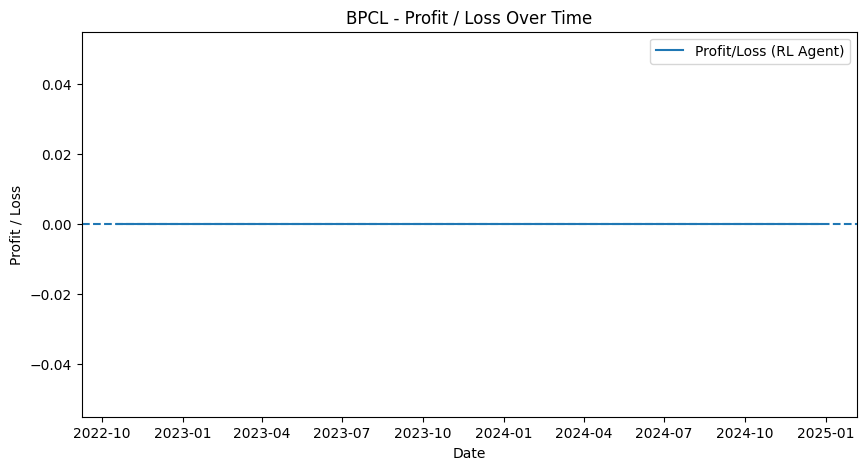

In [30]:
for stock in top10:

    stock_test = test_df[test_df['Name'] == stock]

    actions, portfolio, rewards = test_dqn(dqn_models[stock], stock_test)

    portfolio = pd.Series(portfolio)

    profit_loss_curve = portfolio - portfolio.iloc[0]

    plt.figure(figsize=(10,5))
    plt.plot(stock_test['date'].iloc[:len(profit_loss_curve)],
             profit_loss_curve,
             label="Profit/Loss (RL Agent)")

    plt.axhline(0, linestyle='--')
    plt.title(f"{stock} - Profit / Loss Over Time")
    plt.xlabel("Date")
    plt.ylabel("Profit / Loss")
    plt.legend()
    plt.show()

In [31]:
results = []

for stock in top10:

    stock_test = test_df[test_df['Name'] == stock]

    actions, portfolio, rewards = test_dqn(dqn_models[stock], stock_test)

    portfolio = pd.Series(portfolio)

    # RL Return %
    rl_return_pct = ((portfolio.iloc[-1] - portfolio.iloc[0])
                     / portfolio.iloc[0]) * 100

    # Buy & Hold Return %
    first_price = stock_test.iloc[0]['close']
    last_price = stock_test.iloc[-1]['close']
    bh_return_pct = ((last_price - first_price) / first_price) * 100

    # Difference %
    difference = rl_return_pct - bh_return_pct

    results.append([
        stock,
        round(rl_return_pct,2),
        round(bh_return_pct,2),
        round(difference,2)
    ])

percentage_df = pd.DataFrame(results,
                             columns=[
                                 "Stock",
                                 "RL Return (%)",
                                 "BuyHold Return (%)",
                                 "Outperformance (%)"
                             ])

# Rank by RL performance
percentage_df = percentage_df.sort_values("RL Return (%)", ascending=False)

percentage_df

,Stock,RL Return (%),BuyHold Return (%),Outperformance (%)
5,BAJAJ-AUTO,125.49,152.60,-27.11
8,BHARTIARTL,109.58,104.70,4.88
2,APOLLOHOSP,59.27,68.47,-9.20
1,ADANIPORTS,49.46,52.10,-2.64
4,AXISBANK,19.81,31.30,-11.49
7,BAJFINANCE,0.00,-5.93,5.93
9,BPCL,0.00,116.76,-116.76
6,BAJAJFINSV,0.00,-8.56,8.56
3,ASIANPAINT,-2.69,-27.55,24.86
0,ADANIENT,-15.48,-21.00,5.52


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


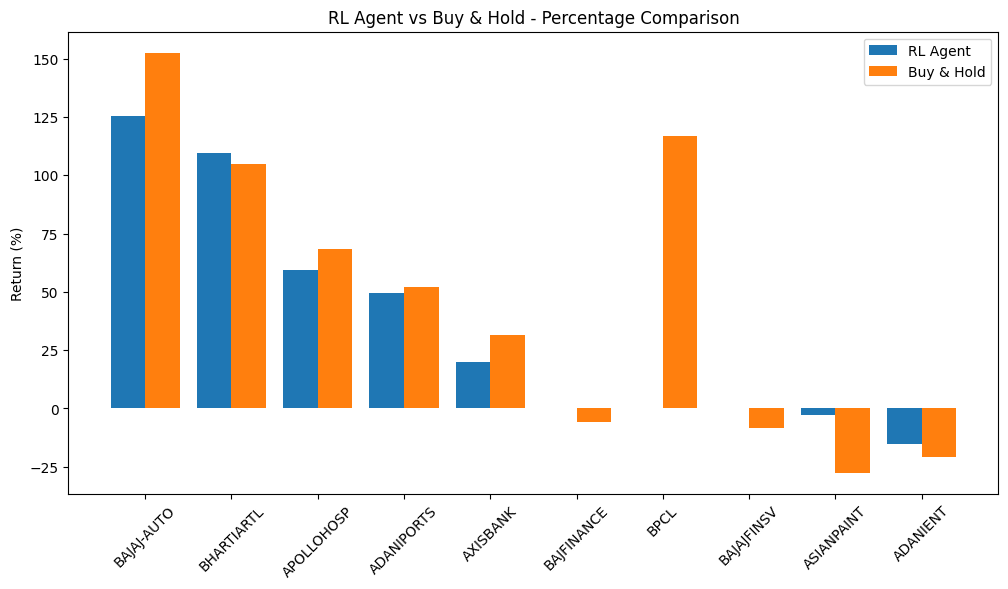

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
import matplotlib.pyplot as plt

x = np.arange(len(percentage_df["Stock"]))

plt.figure(figsize=(12,6))

plt.bar(x - 0.2, percentage_df["RL Return (%)"],
        width=0.4, label="RL Agent")

plt.bar(x + 0.2, percentage_df["BuyHold Return (%)"],
        width=0.4, label="Buy & Hold")

plt.xticks(x, percentage_df["Stock"], rotation=45)
plt.ylabel("Return (%)")
plt.title("RL Agent vs Buy & Hold - Percentage Comparison")
plt.legend()
plt.show()

In [33]:
best_stock = percentage_df.iloc[0]
worst_stock = percentage_df.iloc[-1]

print("Best Stock Based on RL Return:")
print(best_stock)

print("\nWorst Performing Stock:")
print(worst_stock)

Best Stock Based on RL Return:
Stock                 BAJAJ-AUTO
RL Return (%)             125.49
BuyHold Return (%)         152.6
Outperformance (%)        -27.11
Name: 5, dtype: object

Worst Performing Stock:
Stock                 ADANIENT
RL Return (%)           -15.48
BuyHold Return (%)       -21.0
Outperformance (%)        5.52
Name: 0, dtype: object


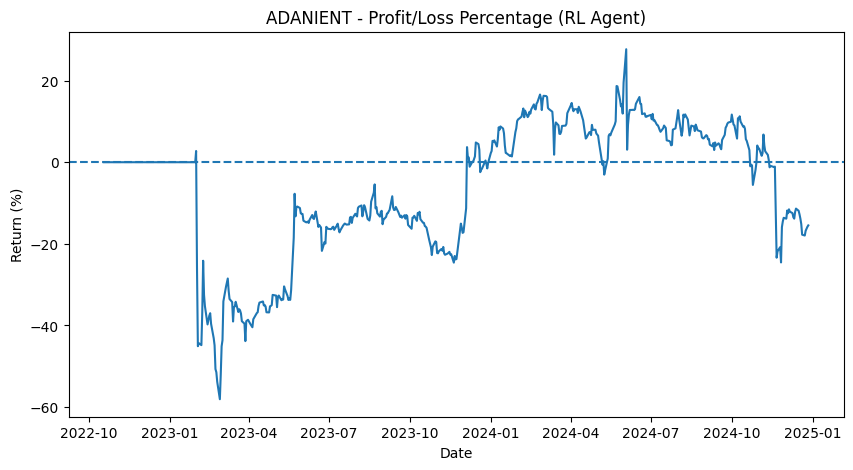

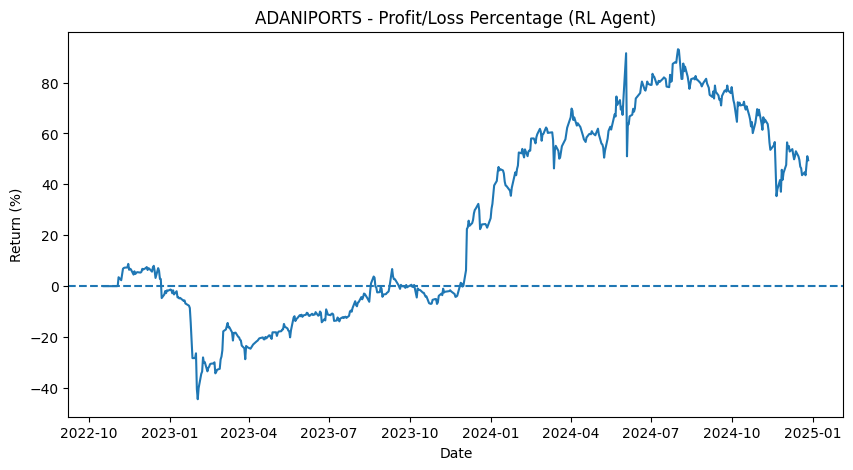

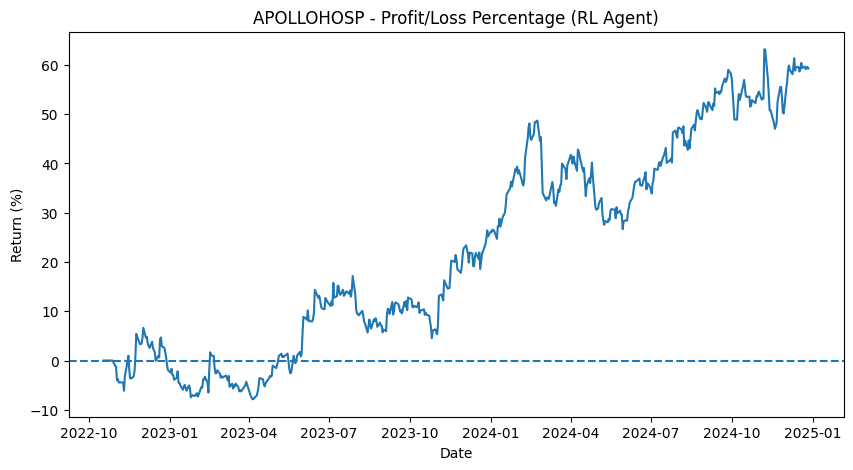

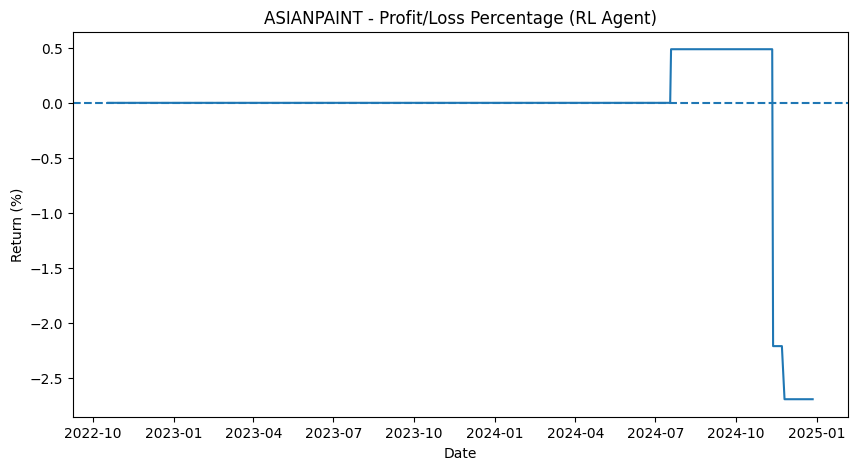

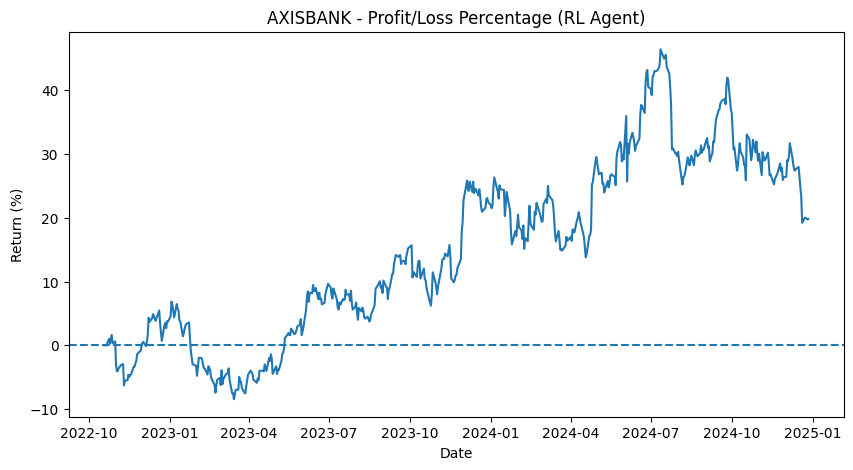

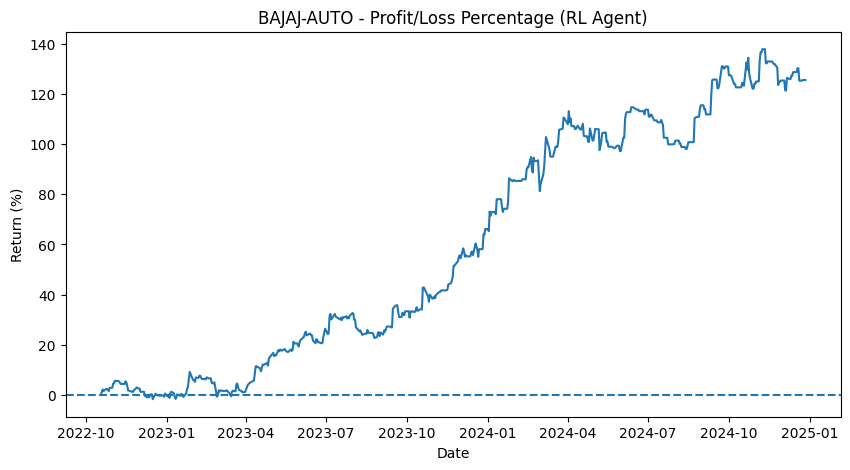

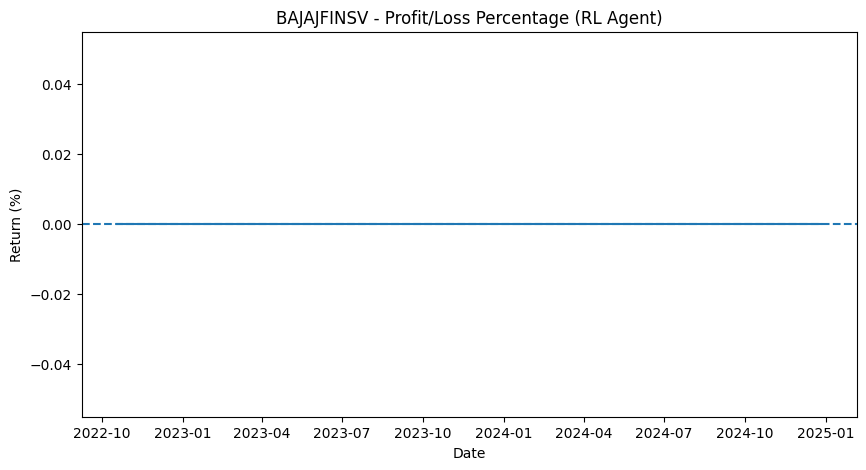

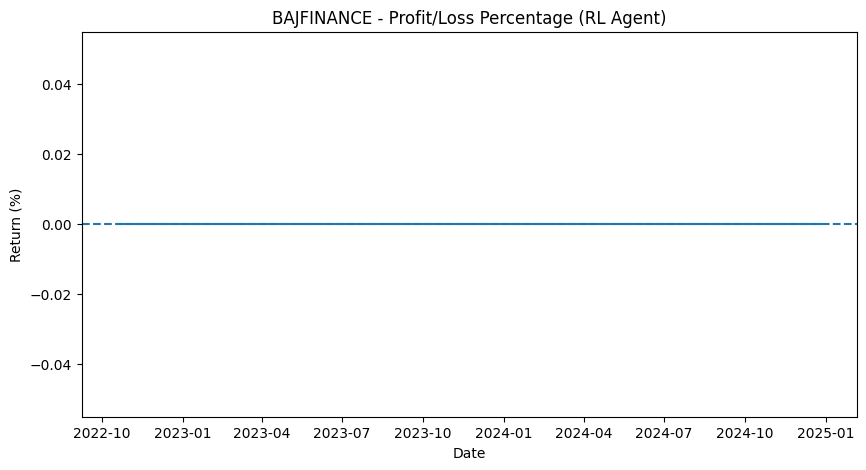

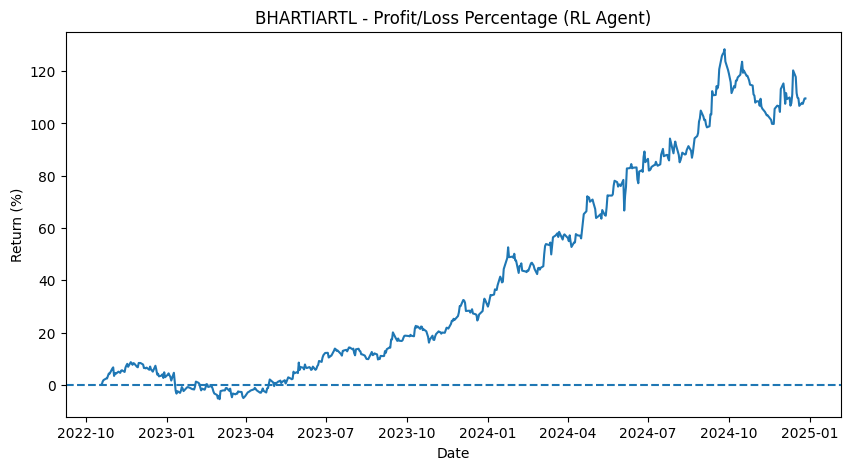

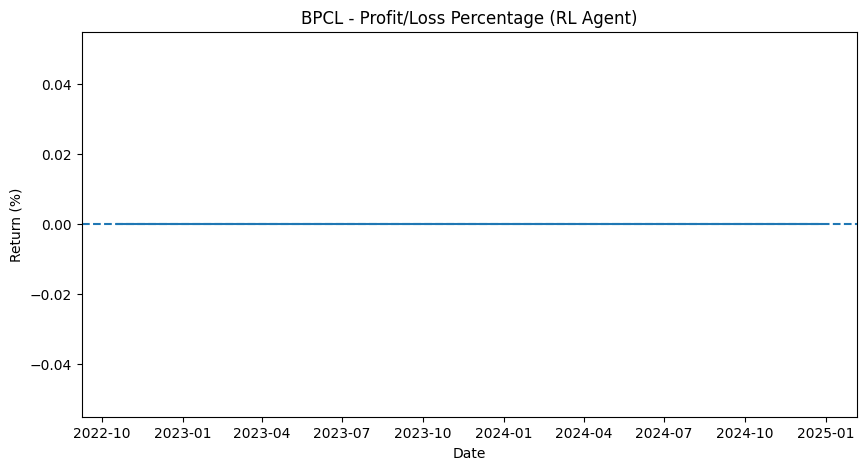

In [34]:
for stock in top10:

    stock_test = test_df[test_df['Name'] == stock]

    actions, portfolio, rewards = test_dqn(dqn_models[stock], stock_test)

    portfolio = pd.Series(portfolio)

    profit_pct_curve = ((portfolio - portfolio.iloc[0])
                        / portfolio.iloc[0]) * 100

    plt.figure(figsize=(10,5))
    plt.plot(stock_test['date'].iloc[:len(profit_pct_curve)],
             profit_pct_curve)

    plt.axhline(0, linestyle='--')
    plt.title(f"{stock} - Profit/Loss Percentage (RL Agent)")
    plt.xlabel("Date")
    plt.ylabel("Return (%)")
    plt.show()

In [56]:
dqn_models_v2 = {}

for stock in top10:

    stock_train = train_df[train_df['Name'] == stock]
    env = TradingEnv(stock_train)

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=3e-5,
        batch_size=64,
        buffer_size=20000,
        gamma=0.995,
        exploration_fraction=0.2,
        exploration_final_eps=0.02,
        target_update_interval=250,
        verbose=0
    )

    model.learn(total_timesteps=90000)
    dqn_models_v2[stock] = model

In [57]:
def test_model(model, data):

    env = TradingEnv(data)
    obs, _ = env.reset()
    done = False

    portfolio = []
    rewards = []

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        portfolio.append(env.portfolio_values[-1])
        rewards.append(reward)

    return portfolio, rewards

In [58]:
def evaluate_models(models_dict):

    results = []

    for stock in top10:

        stock_test = test_df[test_df['Name']==stock]
        portfolio, rewards = test_model(models_dict[stock], stock_test)

        portfolio = pd.Series(portfolio)
        returns = portfolio.pct_change().dropna()

        rl_return = ((portfolio.iloc[-1] - portfolio.iloc[0])
                     / portfolio.iloc[0]) * 100

        sharpe = (returns.mean()/returns.std())*np.sqrt(252) if returns.std()!=0 else 0
        volatility = returns.std()*np.sqrt(252)
        total_reward = sum(rewards)

        first_price = stock_test.iloc[0]['close']
        last_price = stock_test.iloc[-1]['close']
        bh_return = ((last_price - first_price)/first_price)*100

        results.append([stock, rl_return, bh_return,
                        sharpe, volatility, total_reward])

    df_result = pd.DataFrame(results,
                             columns=["Stock",
                                      "RL Return (%)",
                                      "BuyHold Return (%)",
                                      "Sharpe Ratio",
                                      "Volatility",
                                      "Total Reward"])

    df_result = df_result.sort_values("RL Return (%)", ascending=False)
    return df_result

In [61]:
results_v2 = evaluate_models(dqn_models_v2)
print(results)

[['ADANIENT', np.float64(2591.065673828125), np.float64(-15578.609498046877), np.float64(-0.15578609498046878), np.float64(-0.20999302891567073)], ['ADANIPORTS', np.float64(1212.6004638671875), np.float64(49473.86351757814), np.float64(0.49473863517578137), np.float64(0.5210256395337131)], ['APOLLOHOSP', np.float64(7284.91064453125), np.float64(59170.32761621094), np.float64(0.5917032761621094), np.float64(0.684730553155662)], ['ASIANPAINT', np.float64(2263.798095703125), np.float64(-3205.129434326169), np.float64(-0.03205129434326169), np.float64(-0.27547870473879427)], ['AXISBANK', np.float64(1069.036376953125), np.float64(19714.80880517578), np.float64(0.1971480880517578), np.float64(0.31300110144583787)], ['BAJAJ-AUTO', np.float64(8562.8828125), np.float64(60914.63951000974), np.float64(0.6097458251691782), np.float64(1.5259707037371633)], ['BAJAJFINSV', np.float64(1575.93212890625), np.float64(0.0), np.float64(0.0), np.float64(-0.08557506118696984)], ['BAJFINANCE', np.float64(684.

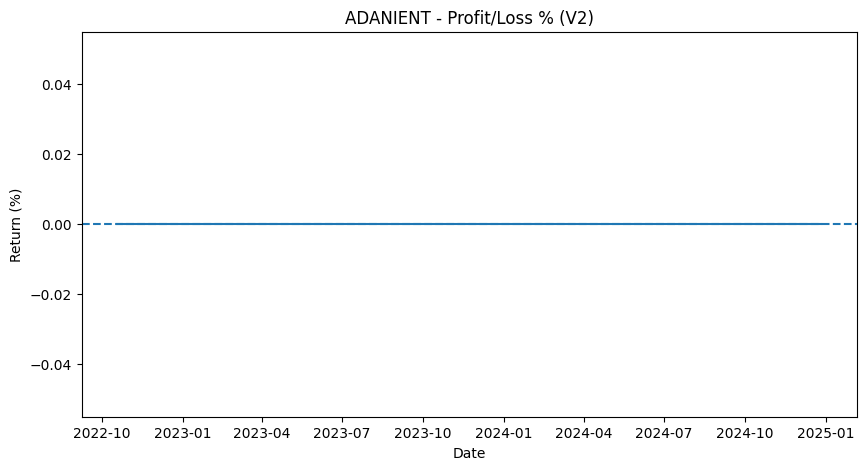

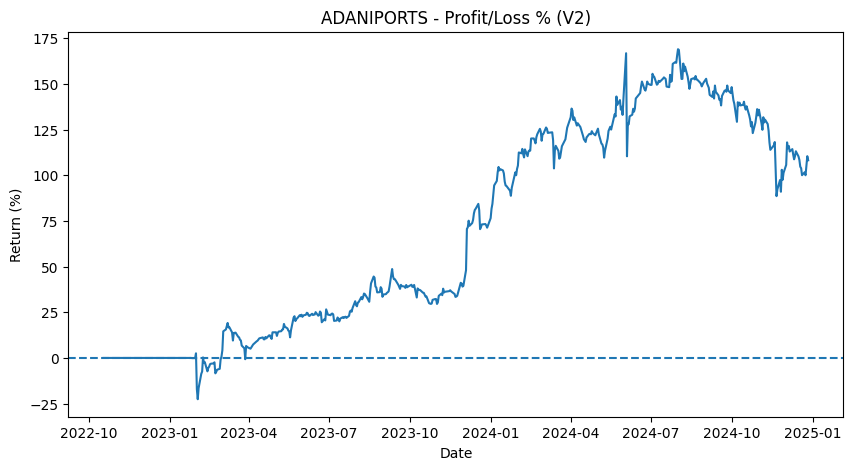

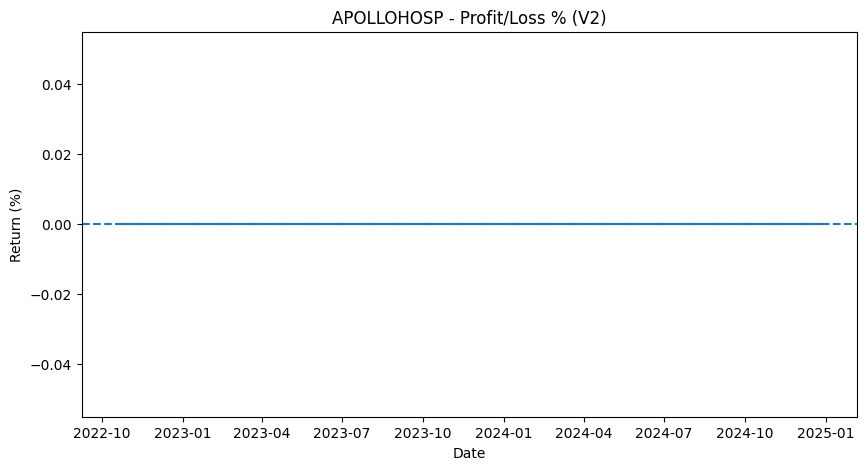

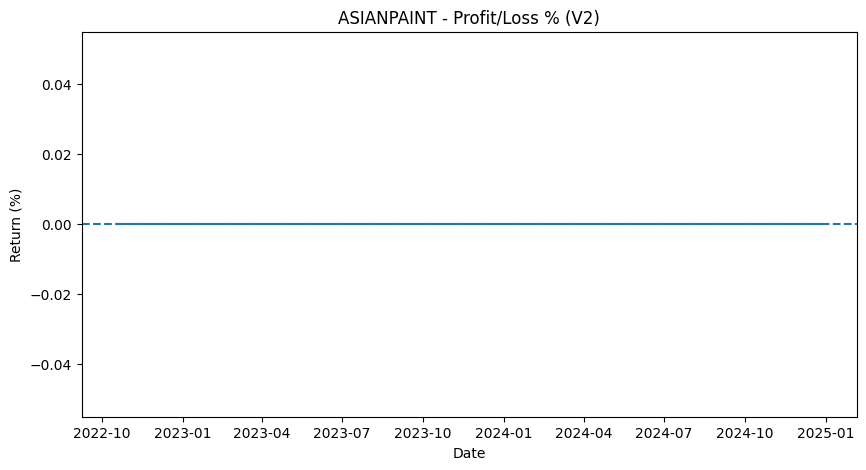

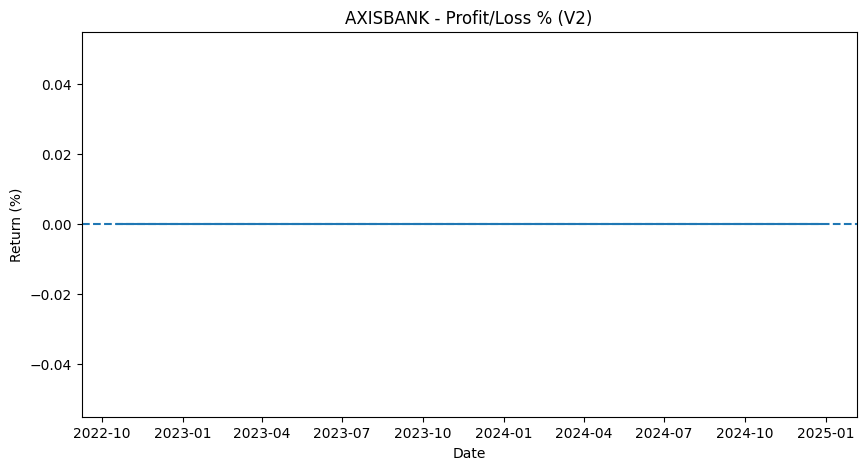

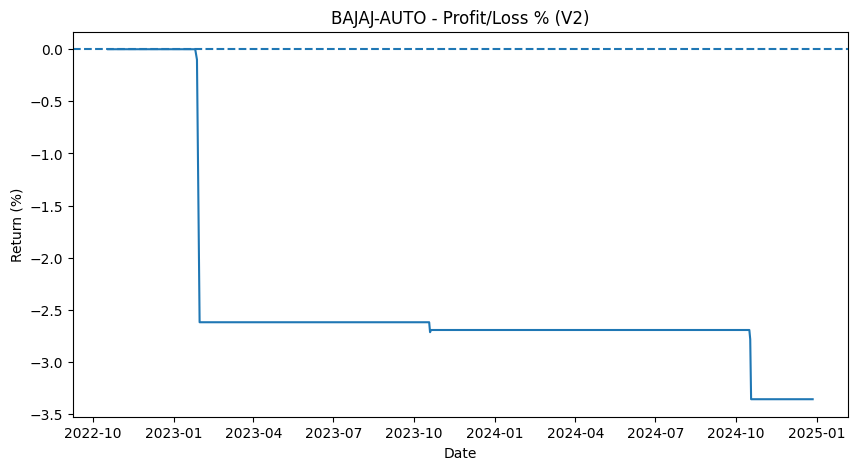

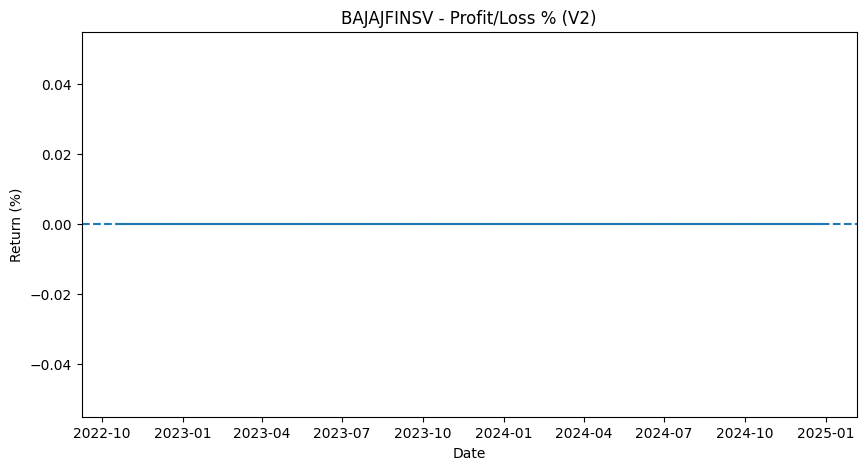

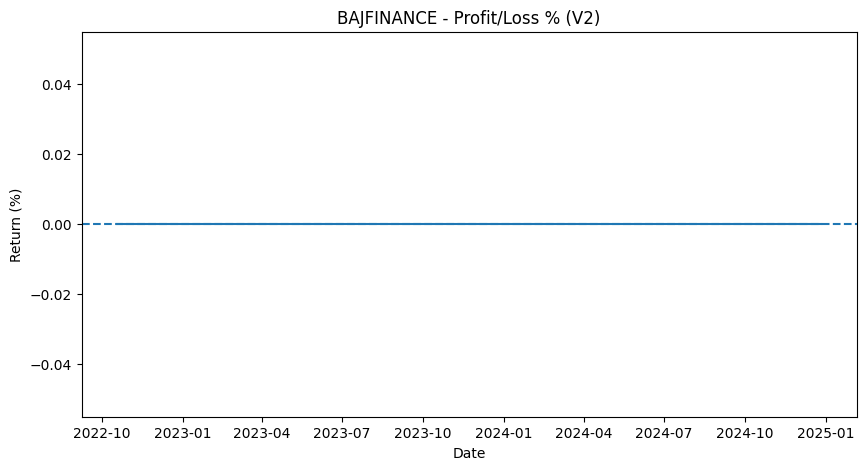

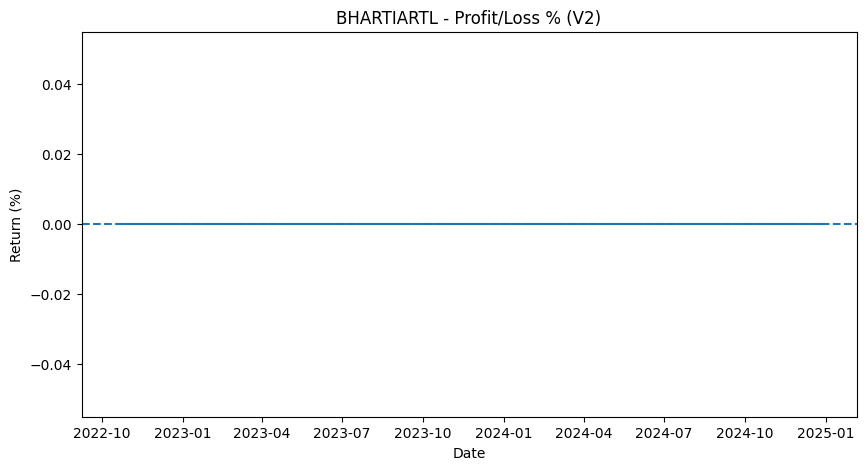

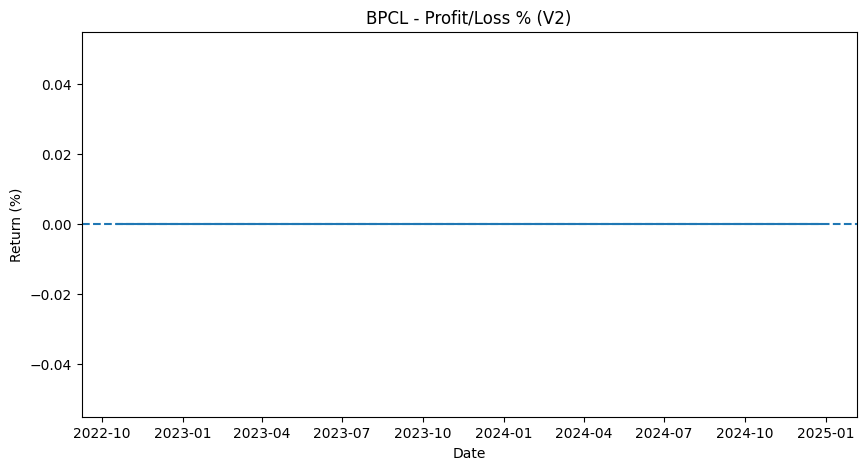

In [60]:
for stock in top10:

    stock_test = test_df[test_df['Name']==stock]
    portfolio, _ = test_model(dqn_models_v2[stock], stock_test)

    portfolio = pd.Series(portfolio)
    profit_pct = ((portfolio - portfolio.iloc[0])
                  / portfolio.iloc[0]) * 100

    plt.figure(figsize=(10,5))
    plt.plot(stock_test['date'].iloc[:len(profit_pct)],
             profit_pct)
    plt.axhline(0, linestyle='--')
    plt.title(f"{stock} - Profit/Loss % (V2)")
    plt.xlabel("Date")
    plt.ylabel("Return (%)")
    plt.show()

In [62]:
results = []

for stock in top10:

    stock_test = test_df[test_df['Name'] == stock]

    actions, portfolio, rewards = test_dqn(dqn_models[stock], stock_test)

    portfolio = pd.Series(portfolio)

    # RL Return %
    rl_return_pct = ((portfolio.iloc[-1] - portfolio.iloc[0])
                     / portfolio.iloc[0]) * 100

    # Buy & Hold Return %
    first_price = stock_test.iloc[0]['close']
    last_price = stock_test.iloc[-1]['close']
    bh_return_pct = ((last_price - first_price) / first_price) * 100

    # Difference %
    difference = rl_return_pct - bh_return_pct

    results.append([
        stock,
        round(rl_return_pct,2),
        round(bh_return_pct,2),
        round(difference,2)
    ])

percentage_df = pd.DataFrame(results,
                             columns=[
                                 "Stock",
                                 "RL Return (%)",
                                 "BuyHold Return (%)",
                                 "Outperformance (%)"
                             ])

# Rank by RL performance
percentage_df = percentage_df.sort_values("RL Return (%)", ascending=False)

percentage_df

,Stock,RL Return (%),BuyHold Return (%),Outperformance (%)
8,BHARTIARTL,108.43,104.70,3.73
5,BAJAJ-AUTO,60.97,152.60,-91.62
2,APOLLOHOSP,59.17,68.47,-9.30
1,ADANIPORTS,49.47,52.10,-2.63
4,AXISBANK,19.71,31.30,-11.59
7,BAJFINANCE,0.00,-5.93,5.93
9,BPCL,0.00,116.76,-116.76
6,BAJAJFINSV,0.00,-8.56,8.56
3,ASIANPAINT,-3.21,-27.55,24.34
0,ADANIENT,-15.58,-21.00,5.42


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [63]:
action_map = {0:"HOLD", 1:"BUY", 2:"SELL"}

suggestions = []

for stock in top10:
    stock_test = test_df[test_df['Name'] == stock]
    # Updated to unpack 3 values from test_dqn
    actions, _, _ = test_dqn(dqn_models[stock], stock_test)
    last_action = actions[-1]

    # Convert numpy array to integer before using as a dictionary key
    suggestions.append([stock, action_map[int(last_action)]])

suggestions_df = pd.DataFrame(suggestions,
                              columns=["Stock","Suggested Action"])

suggestions_df

,Stock,Suggested Action
0,ADANIENT,BUY
1,ADANIPORTS,BUY
2,APOLLOHOSP,HOLD
3,ASIANPAINT,SELL
4,AXISBANK,BUY
5,BAJAJ-AUTO,HOLD
6,BAJAJFINSV,SELL
7,BAJFINANCE,SELL
8,BHARTIARTL,BUY
9,BPCL,HOLD


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [64]:
results_v1 = evaluate_models(dqn_models_v1)
results_v2 = evaluate_models(dqn_models_v2)

comparison = results_v1.merge(results_v2,
                               on="Stock",
                               suffixes=("_V1","_V2"))

comparison["Improvement (%)"] = (
    comparison["RL Return (%)_V2"] -
    comparison["RL Return (%)_V1"]
)

comparison

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Stock,RL Return (%)_V1,BuyHold Return (%)_V1,Sharpe Ratio_V1,Volatility_V1,Total Reward_V1,RL Return (%)_V2,BuyHold Return (%)_V2,Sharpe Ratio_V2,Volatility_V2,Total Reward_V2,Improvement (%)
0,BHARTIARTL,110.117952,104.695590,1.923044,0.189605,-29.849203,0.000000,104.695590,0.000000,0.000000,-0.200000,-110.117952
1,BPCL,99.674159,116.757967,1.250935,0.292296,-28.399896,0.000000,116.757967,0.000000,0.000000,-0.200000,-99.674159
2,ADANIPORTS,74.317679,52.102564,0.842788,0.411151,-28.649573,108.218937,52.102564,1.063487,0.398828,-23.699887,33.901258
3,APOLLOHOSP,47.971464,68.473055,0.973499,0.210544,-3.562609,0.000000,68.473055,0.000000,0.000000,-6.000000,-47.971464
4,ADANIENT,0.000000,-20.999303,0.000000,0.000000,0.000000,0.000000,-20.999303,0.000000,0.000000,-53.800000,0.000000
5,AXISBANK,0.000000,31.300110,0.000000,0.000000,-43.600000,0.000000,31.300110,0.000000,0.000000,-54.000000,0.000000
6,BAJFINANCE,0.000000,-5.928687,0.000000,0.000000,-0.100000,0.000000,-5.928687,0.000000,0.000000,-54.100000,0.000000
7,BAJAJ-AUTO,0.000000,152.597070,0.000000,0.000000,-3.200000,-3.358816,152.597070,-0.890318,0.017728,-54.428436,-3.358816
8,BAJAJFINSV,-8.343709,-8.557506,-0.068992,0.224438,-27.149957,0.000000,-8.557506,0.000000,0.000000,-54.100000,8.343709
9,ASIANPAINT,-27.988579,-27.547870,-0.719863,0.188074,-27.149982,0.000000,-27.547870,0.000000,0.000000,0.000000,27.988579


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


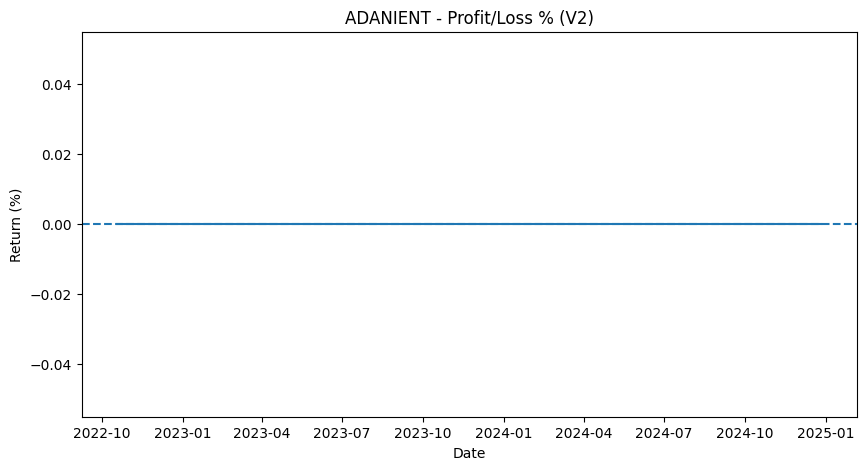

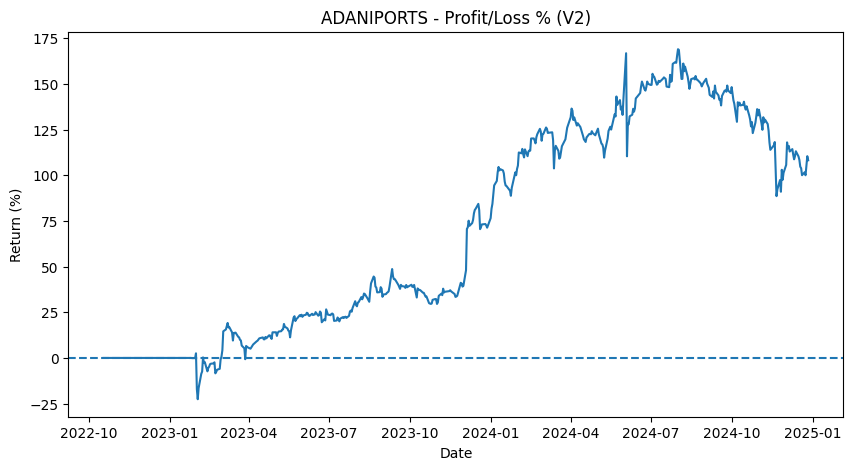

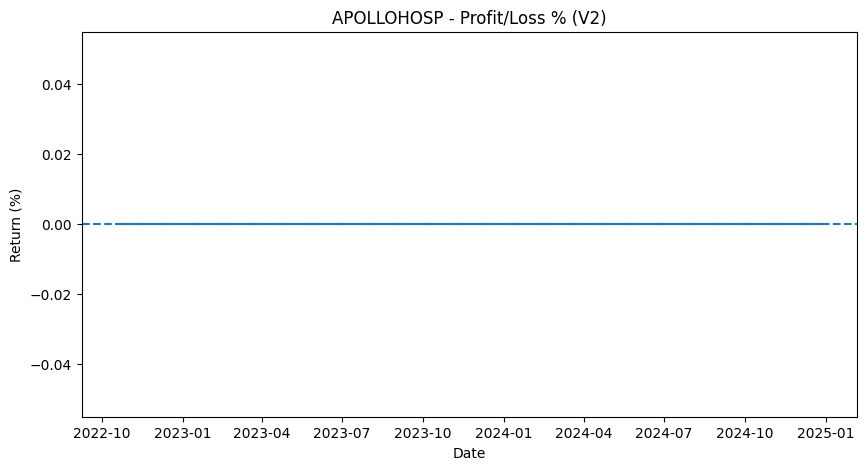

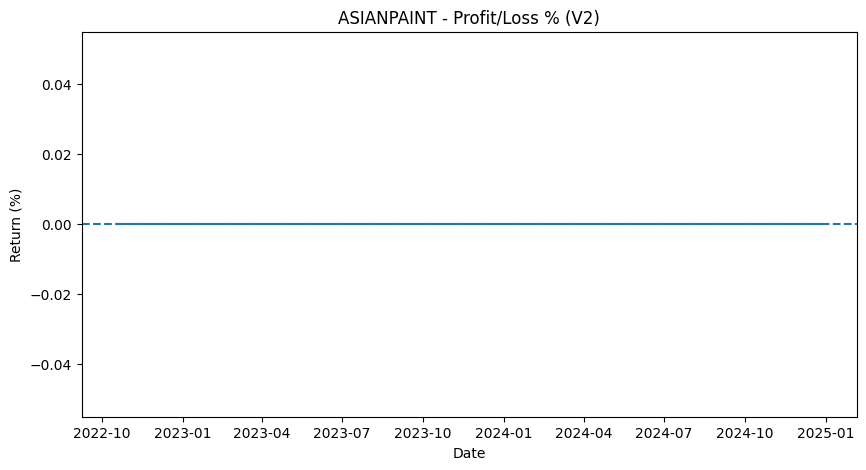

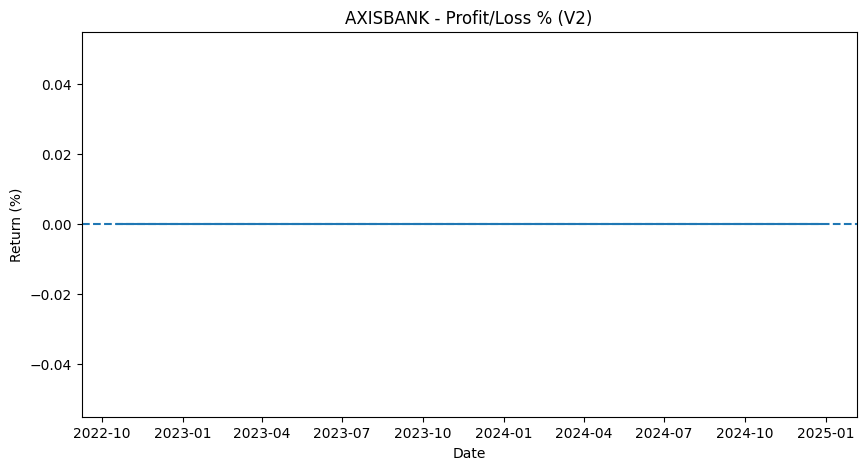

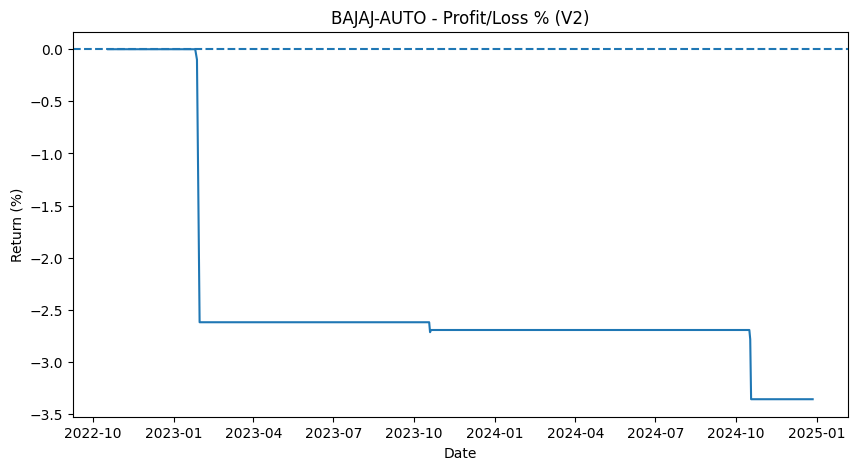

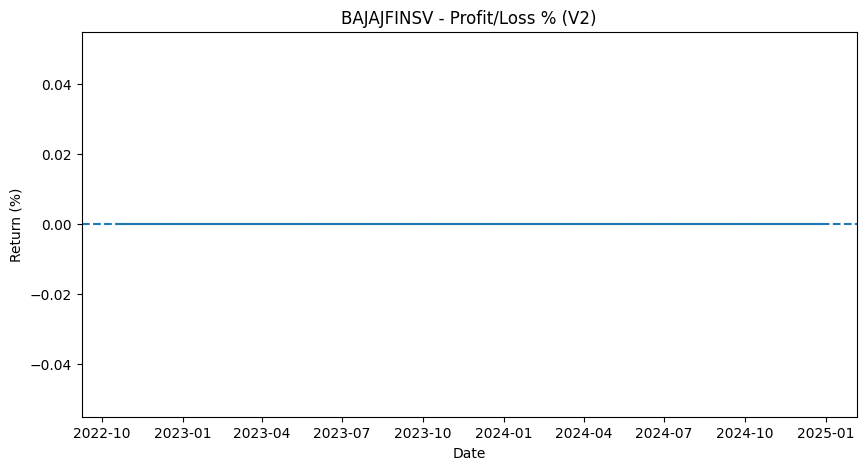

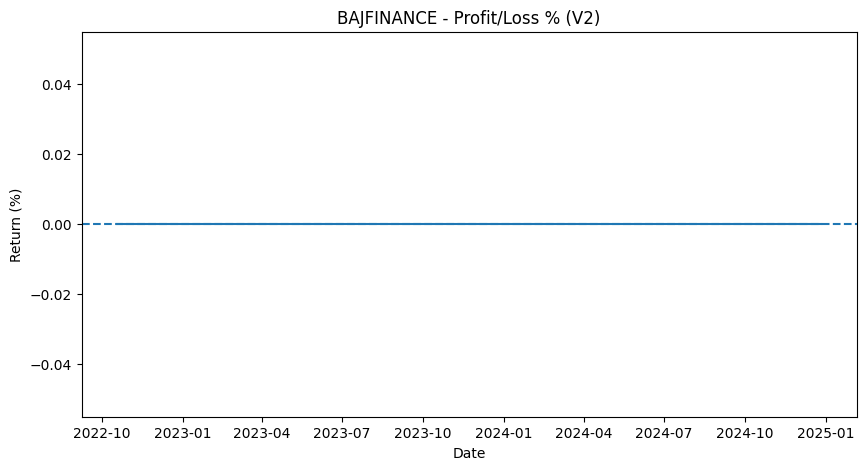

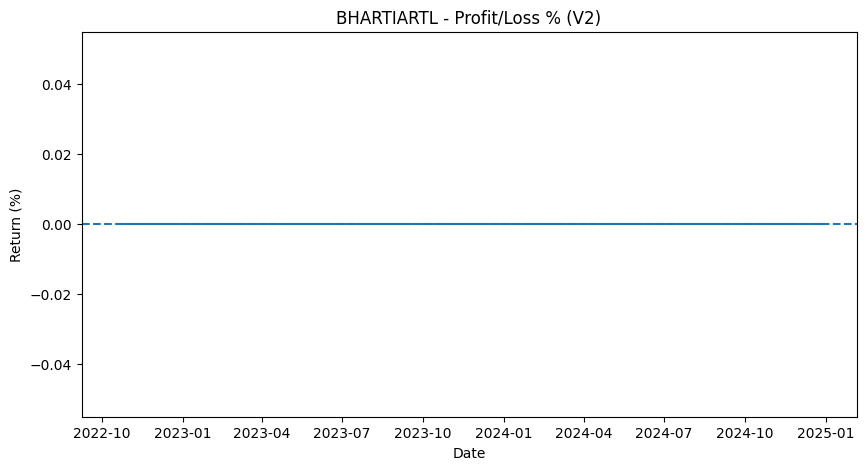

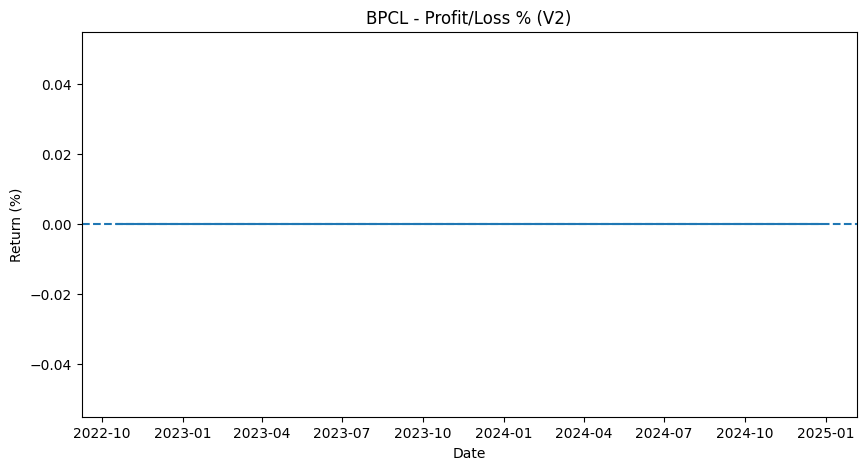

In [65]:
for stock in top10:

    stock_test = test_df[test_df['Name']==stock]
    portfolio, _ = test_model(dqn_models_v2[stock], stock_test)

    portfolio = pd.Series(portfolio)
    profit_pct = ((portfolio - portfolio.iloc[0])
                  / portfolio.iloc[0]) * 100

    plt.figure(figsize=(10,5))
    plt.plot(stock_test['date'].iloc[:len(profit_pct)],
             profit_pct)
    plt.axhline(0, linestyle='--')
    plt.title(f"{stock} - Profit/Loss % (V2)")
    plt.xlabel("Date")
    plt.ylabel("Return (%)")
    plt.show()